# Data Science Salaries Prediction with Time Series Validation

### *Or: How I Learned to Stop Worrying and Love TimeSeriesSplit*

---

**Author:** Applied mathematics and physics Student @ MIPT  
**Goal:** Demonstrate proper time-series validation in salary prediction  
**Key idea:** Most notebooks leak future data — this one doesn't.

[![Kaggle](https://img.shields.io/badge/Kaggle-Notebook-blue)](https://www.kaggle.com/)
[![Python 3.12](https://img.shields.io/badge/Python-3.12-green)](https://www.python.org/)

## 📑 Table of Contents

1. [Exploratory Data Analysis](#eda)
2. [Data Preprocessing](#preprocessing)
3. [Train-Test Split (The Right Way)](#split)
4. [Feature Engineering](#features)
5. [Modeling: Baseline](#baseline)
6. [Modeling: Stacking](#stacking)
7. [Feature Interpretation](#interpretation)
8. [Final Metrics](#metrics)
9. [Conclusions](#conclusions)

In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error

# Category encoders
from category_encoders import OneHotEncoder, TargetEncoder

# Style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [4]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/ruchi798/data-science-job-salaries/ds_salaries.csv


In [9]:
data = pd.read_csv('/kaggle/input/datasets/ruchi798/data-science-job-salaries/ds_salaries.csv', 
                   sep=',', index_col=0)
print(f"\n Data loaded: {data.shape[0]} rows, {data.shape[1]} columns")
data.head()


 Data loaded: 607 rows, 11 columns


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


## 🔎 Exploratory Data Analysis

Let's first understand what we're dealing with:

In [10]:
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 607 entries, 0 to 606
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           607 non-null    int64 
 1   experience_level    607 non-null    object
 2   employment_type     607 non-null    object
 3   job_title           607 non-null    object
 4   salary              607 non-null    int64 
 5   salary_currency     607 non-null    object
 6   salary_in_usd       607 non-null    int64 
 7   employee_residence  607 non-null    object
 8   remote_ratio        607 non-null    int64 
 9   company_location    607 non-null    object
 10  company_size        607 non-null    object
dtypes: int64(4), object(7)
memory usage: 56.9+ KB


,work_year,salary,salary_in_usd,remote_ratio
count,607.000000,6.070000e+02,607.000000,607.00000
mean,2021.405272,3.240001e+05,112297.869852,70.92257
std,0.692133,1.544357e+06,70957.259411,40.70913
min,2020.000000,4.000000e+03,2859.000000,0.00000
25%,2021.000000,7.000000e+04,62726.000000,50.00000
50%,2022.000000,1.150000e+05,101570.000000,100.00000
75%,2022.000000,1.650000e+05,150000.000000,100.00000
max,2022.000000,3.040000e+07,600000.000000,100.00000


### 🎯 Target: `salary`

We drop `salary_in_usd` to avoid target leakage:

In [11]:
data.drop('salary_in_usd', axis=1, inplace=True)

We divide the signs into **numeric** and **categorical** ones.

In [21]:
numeric_cols = data.select_dtypes(exclude='object').columns
categorical_cols = data.select_dtypes(include='object').columns

#### Distribution Analysis

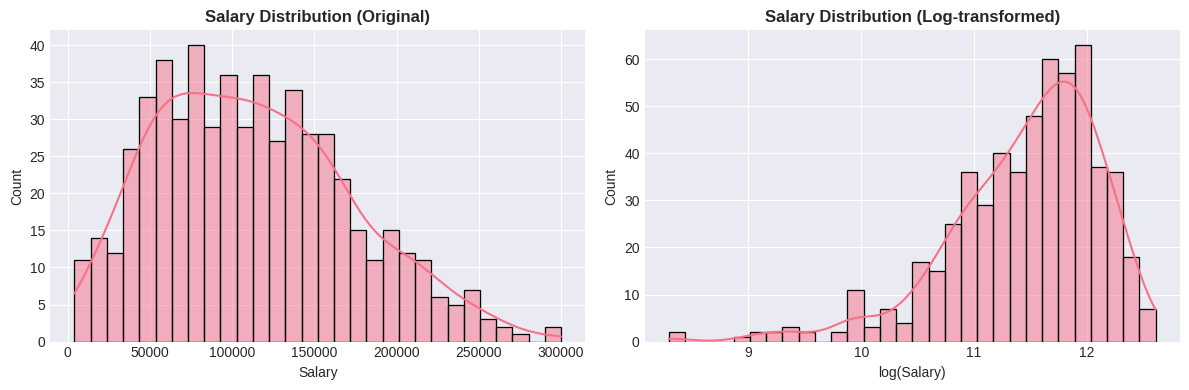

In [15]:
def data_filter_iqr(data: pd.DataFrame, col: str, iqr_coef: float = 1.5) -> tuple:
    Q1 = np.quantile(data[col], q=0.25)
    Q3 = np.quantile(data[col], q=0.75)
    IQR = Q3 - Q1
    return Q3 + iqr_coef * IQR, Q1 - iqr_coef * IQR

upper_iqr, lower_iqr = data_filter_iqr(data,'salary')

filtered_data = data[(data['salary'] >= lower_iqr) & (data['salary'] <= upper_iqr)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Original
sns.histplot(filtered_data['salary'], bins=30, kde=True, ax=axes[0])
axes[0].set_title('Salary Distribution (Original)', fontweight='bold')
axes[0].set_xlabel('Salary')

# Log-transformed
sns.histplot(np.log1p(filtered_data['salary']), bins=30, kde=True, ax=axes[1])
axes[1].set_title('Salary Distribution (Log-transformed)', fontweight='bold')
axes[1].set_xlabel('log(Salary)')

plt.tight_layout()
plt.show()

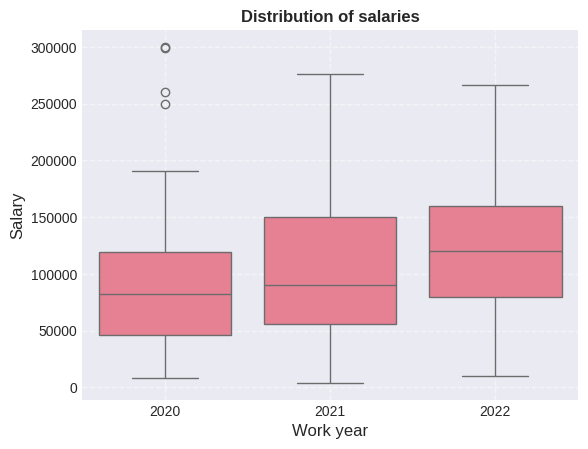

In [16]:
sns.boxplot(data=data[(data['salary'] >= lower_iqr) & (data['salary'] <= upper_iqr)], 
            x='work_year', 
            y='salary')
plt.ylabel('Salary', fontsize=12)
plt.yticks(fontsize=10)
plt.xlabel('Work year', fontsize=12)
plt.xticks(fontsize=10)
plt.title('Distribution of salaries', fontweight='bold')
plt.grid(True, alpha=0.5, linestyle='--', linewidth=1)
plt.show()

* #### Thus, we have confirmed with the help of boxplots that our **target variable depends** on the **work year**.
* #### We can see that **salaries** are **rising** every year and the **median** for the trait is also **different**.


### 📊 Categorical Features Impact

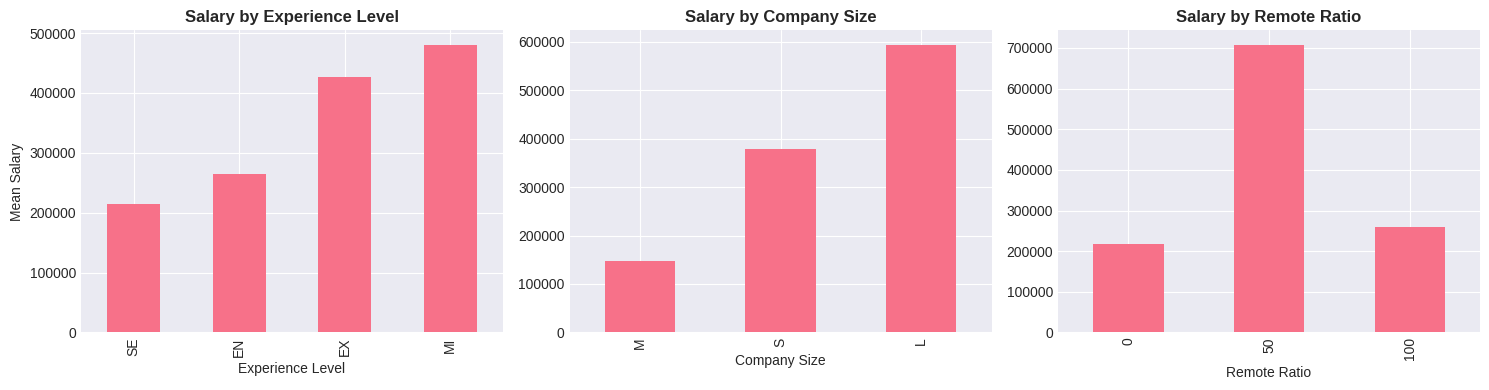

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Experience level
data.groupby('experience_level')['salary'].mean().sort_values().plot(kind='bar', ax=axes[0])
axes[0].set_title('Salary by Experience Level', fontweight='bold')
axes[0].set_ylabel('Mean Salary')
axes[0].set_xlabel('Experience Level')

# Company size
data.groupby('company_size')['salary'].mean().sort_values().plot(kind='bar', ax=axes[1])
axes[1].set_title('Salary by Company Size', fontweight='bold')
axes[1].set_xlabel('Company Size')

# Remote ratio
data.groupby('remote_ratio')['salary'].mean().plot(kind='bar', ax=axes[2])
axes[2].set_title('Salary by Remote Ratio', fontweight='bold')
axes[2].set_xlabel('Remote Ratio')

plt.tight_layout()
plt.show()

The prevalence of the hybrid may affect this, let's check!

In [163]:
data['remote_ratio'].value_counts(normalize=True)

remote_ratio
100    0.627677
0      0.209226
50     0.163097
Name: proportion, dtype: float64

Interestingly, it's an experimental field again, and after that we'll evaluate the importance of features for the model.

> **Note:** `experience_level` and `company_size` are **ordinal** — we'll preserve their order.
> `remote_ratio` will be treated as categorical.

* Next, we could go deeper into solving the problem and translate all the features into numbers and evaluate multicollinearity. 
* But here we will only check the collinearity of the current initial features.

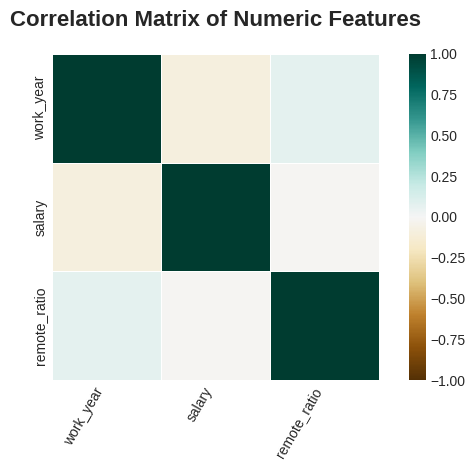

In [22]:
sns.heatmap(data=data[numeric_cols].corr(),
            xticklabels=data[numeric_cols].corr().columns,
            yticklabels=data[numeric_cols].corr().columns,
            linewidths=0.5,
            square=True,
            vmin=-1,
            vmax=1,
            cmap='BrBG')
plt.title('Correlation Matrix of Numeric Features', 
          fontsize=16, fontweight='bold', pad=20)
plt.xticks(ha='right', fontsize=10, rotation=60)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

Let's write simple functions to check the correlation!

In [165]:
def get_redundant_pairs(data: pd.DataFrame) -> set:
    pairs_to_drop = set()
    cols = data.columns
    for i in range(0, data.shape[1]):
        for j in range(0, i+1):
            pairs_to_drop.add((cols[i], cols[j]))
    return pairs_to_drop

def get_top_abs_correlations(data: pd.DataFrame, n: int=5) -> pd.Series:
    au_corr = data.corr().abs().unstack()
    labels_to_drop = get_redundant_pairs(data)
    au_corr = au_corr.drop(labels=labels_to_drop).sort_values(ascending=False)
    return au_corr[0:n]

print(get_top_abs_correlations(data[numeric_cols]))

work_year  salary          0.087577
           remote_ratio    0.076314
salary     remote_ratio    0.014608
dtype: float64


Great, let's get down to the very key issue that is often ignored!

## 🕒 The Elephant in the Room: Temporal Data Leakage

Many Kaggle notebooks blindly use `train_test_split` with shuffling, 
allowing the model to "peek" into the future.

**We won't do that.**

> 💡 **Key insight:** We split by `work_year` — train on 2020-2021, test on 2022.
> No future data leaks into training.

In [24]:
data_train = data[data['work_year'] != 2022]
data_test = data[data['work_year'] == 2022]

In [25]:
X_train = data_train.drop('salary', axis=1)
X_test = data_test.drop('salary', axis=1)

In [28]:
y_train = np.log1p(data_train['salary'])
y_test = np.log1p(data_test['salary'])

## 🛠️ Feature Engineering Without Overcomplicating

We avoid the "curse of dimensionality" by smart encoding:

| Feature Type | Method | Reason |
|-------------|--------|--------|
| Low-cardinality categorical | OneHotEncoding | < 10 unique values |
| High-cardinality categorical | TargetEncoding | Preserve signal without explosion |
| Ordinal features | OrdinalEncoder | Preserve natural order (EN < MI < SE < EX) |
| Numerical | StandardScaler | Normalize scale |

In [29]:
object_cols = X_train.select_dtypes(include='object').columns.to_list()
ordinal_cols = ['company_size', 'experience_level']
object_cols = list(set(object_cols) - set(ordinal_cols))
count_cols = X_train.select_dtypes(exclude='object').columns.to_list()

In [30]:
COUNT_FOR_OHE = 10

* Let's not thoughtlessly shove all the signs into the OHE. 
* Before that, we identified a lot of categorical features, and now, in order to avoid the curse of dimensionality (we have little data), we will avoid a stack of a huge number of features.

In [31]:
cols_for_ohe = [x for x in object_cols if X_train[x].nunique() < COUNT_FOR_OHE]
cols_for_mte = [x for x in object_cols if X_train[x].nunique() >= COUNT_FOR_OHE]

In [32]:
cols_for_ohe_idx = [list(X_train.columns).index(col) for col in cols_for_ohe]
cols_for_mte_idx = [list(X_train.columns).index(col) for col in cols_for_mte]
count_cols_idx = [list(X_train.columns).index(col) for col in count_cols]

If we do it safely, we'll transfer the indexes to the transformer!

In [34]:
size_ordinal = ordinal_cols[0]
size_group = [X_train[size_ordinal].value_counts().index.to_list()]

exp_ordinal = ordinal_cols[1]
exp_group = [X_train[exp_ordinal].value_counts().index.to_list()]

We'll make the processing as simple as possible, but we're not writing to production.

In [35]:
t = [('OneHotEncoder', OneHotEncoder(handle_unknown='ignore'), cols_for_ohe_idx),
     ('MeanTargetEncoder', TargetEncoder(), cols_for_mte_idx),
     ('StandardScaler', StandardScaler(), count_cols_idx),
     ('exp_ordinal', OrdinalEncoder(categories=exp_group), [exp_ordinal]),
     ('size_ordinal', OrdinalEncoder(categories=size_group), [size_ordinal])
     ]

In [36]:
cols_transform = ColumnTransformer(transformers=t)

In [37]:
cols_transform.fit(X_train, y_train)
cols_transform.transform(X_test)

array([[ 1.        ,  0.        ,  0.        , ...,  0.84828478,
         1.        ,  2.        ],
       [ 1.        ,  0.        ,  0.        , ...,  0.84828478,
         1.        ,  2.        ],
       [ 1.        ,  0.        ,  0.        , ...,  0.84828478,
         1.        ,  2.        ],
       ...,
       [ 1.        ,  0.        ,  0.        , ..., -1.80203199,
         1.        ,  2.        ],
       [ 1.        ,  0.        ,  0.        , ...,  0.84828478,
         1.        ,  2.        ],
       [ 1.        ,  0.        ,  0.        , ...,  0.84828478,
         0.        ,  0.        ]])

## 🐪 → 🐘 Enough Camel, Meet Elephant

We've done all the prep work. Now it's time to fit some models.

In [38]:
splitter = TimeSeriesSplit(n_splits=3)

* #### First, let's build an ordinary **linear regression**. We're doing it smart. 
* #### We go from simple to complex. And we need a certain baseline. Stacking, I'll always have time to write!

In [39]:
pipe_lasso = Pipeline([('columns_transformer', cols_transform),
                       ('lasso', Lasso())])

pipe_lasso.fit(X_train, y_train)

Pipeline(steps=[('columns_transformer',
                 ColumnTransformer(transformers=[('OneHotEncoder',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  [2]),
                                                 ('MeanTargetEncoder',
                                                  TargetEncoder(),
                                                  [4, 7, 3, 5]),
                                                 ('StandardScaler',
                                                  StandardScaler(), [0, 6]),
                                                 ('exp_ordinal',
                                                  OrdinalEncoder(categories=[['MI',
                                                                              'SE',
                                                                              'EN',
                                                                              'EX']]),
                                                  ['experience_level']),
                                                 ('size_ordinal',
                                                  OrdinalEncoder(categories=[['L',
                                                                              'S',
                                                                              'M']]),
                                                  ['company_size'])])),
                ('lasso', Lasso())])

In [40]:
params_for_lasso = {'lasso__alpha' : np.linspace(0.001, 1, num=50)}
search_lasso = GridSearchCV(estimator=pipe_lasso, param_grid=params_for_lasso, 
                            cv=splitter, scoring='neg_mean_squared_error', verbose=20)

In [41]:
search_lasso.fit(X_train, y_train)

Fitting 3 folds for each of 50 candidates, totalling 150 fits
[CV 1/3; 1/50] START lasso__alpha=0.001.........................................
[CV 1/3; 1/50] END .........lasso__alpha=0.001;, score=-1.083 total time=   0.1s
[CV 2/3; 1/50] START lasso__alpha=0.001.........................................
[CV 2/3; 1/50] END .........lasso__alpha=0.001;, score=-1.393 total time=   0.1s
[CV 3/3; 1/50] START lasso__alpha=0.001.........................................
[CV 3/3; 1/50] END .........lasso__alpha=0.001;, score=-0.519 total time=   0.1s
[CV 1/3; 2/50] START lasso__alpha=0.021387755102040818..........................
[CV 1/3; 2/50] END lasso__alpha=0.021387755102040818;, score=-0.967 total time=   0.0s
[CV 2/3; 2/50] START lasso__alpha=0.021387755102040818..........................
[CV 2/3; 2/50] END lasso__alpha=0.021387755102040818;, score=-1.277 total time=   0.0s
[CV 3/3; 2/50] START lasso__alpha=0.021387755102040818..........................
[CV 3/3; 2/50] END lasso__alpha=0.0

GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=3, test_size=None),
             estimator=Pipeline(steps=[('columns_transformer',
                                        ColumnTransformer(transformers=[('OneHotEncoder',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         [2]),
                                                                        ('MeanTargetEncoder',
                                                                         TargetEncoder(),
                                                                         [4, 7,
                                                                          3,
                                                                          5]),
                                                                        ('StandardScaler',
                                                                         StandardScaler(),
                                                                         [0,
                                                                          6]),
                                                                        ('exp_ordinal',
                                                                         OrdinalEncoder(cat...
       0.4087551 , 0.42914286, 0.44953061, 0.46991837, 0.49030612,
       0.51069388, 0.53108163, 0.55146939, 0.57185714, 0.5922449 ,
       0.61263265, 0.63302041, 0.65340816, 0.67379592, 0.69418367,
       0.71457143, 0.73495918, 0.75534694, 0.77573469, 0.79612245,
       0.8165102 , 0.83689796, 0.85728571, 0.87767347, 0.89806122,
       0.91844898, 0.93883673, 0.95922449, 0.97961224, 1.        ])},
             scoring='neg_mean_squared_error', verbose=20)

In [42]:
print(f"Best param for Lasso = ({search_lasso.best_params_})")
print(f"Best result (MSLE) on train = {abs(search_lasso.best_score_):.3f}")
print(f'Best reuslt on test = {abs(search_lasso.score(X_test, y_test)):.3f}')

Best param for Lasso = ({'lasso__alpha': np.float64(0.041775510204081635)})
Best result (MSLE) on train = 0.889
Best reuslt on test = 0.223


Yes, the coefficient of regularization must be selected. Let's do it!

In [43]:
pipe_lasso = Pipeline([('columns_transformer', cols_transform),
                       ('lasso', Lasso(alpha=search_lasso.best_params_['lasso__alpha']))])

pipe_lasso.fit(X_train, y_train)
print(f"Beast result for linear regression {pipe_lasso.score(X_test, y_test):.3f}")

Beast result for linear regression 0.468


Don't worry about it yet - we didn't do any cross-validation.

In [44]:
cv_pipe_lasso = cross_validate(estimator=pipe_lasso, X=X_train, y=y_train, 
                                scoring='neg_mean_squared_error',
                                cv=splitter, 
                                return_train_score=True)

losses_train_pipe = -cv_pipe_lasso['train_score']
print(f"MSLE on train = {np.mean(losses_train_pipe):.3f}")
losses_val_pipe = -cv_pipe_lasso['test_score']
print(f"MSLE on test = {np.mean(losses_val_pipe):.3f}")
print(f"Best pipe with Lasso MSLE-score = {np.mean((pipe_lasso.predict(X_test) - y_test)**2):.3f}")

MSLE on train = 0.530
MSLE on test = 0.889
Best pipe with Lasso MSLE-score = 0.223


In [45]:
pipe_lasso.named_steps['lasso'].coef_

array([ 0.        ,  0.        , -0.        , -0.        ,  0.76820379,
        0.04048819,  0.        ,  1.00360761, -0.        , -0.        ,
       -0.        , -0.12458131])

The classic model. 
The weights of our hyperplane are normal, which will allow us to continue working with the model parameters.

In [46]:
cols_transform

ColumnTransformer(transformers=[('OneHotEncoder',
                                 OneHotEncoder(handle_unknown='ignore'), [2]),
                                ('MeanTargetEncoder', TargetEncoder(),
                                 [4, 7, 3, 5]),
                                ('StandardScaler', StandardScaler(), [0, 6]),
                                ('exp_ordinal',
                                 OrdinalEncoder(categories=[['MI', 'SE', 'EN',
                                                             'EX']]),
                                 ['experience_level']),
                                ('size_ordinal',
                                 OrdinalEncoder(categories=[['L', 'S', 'M']]),
                                 ['company_size'])])

In [49]:
ohe_cols_lasso = pipe_lasso.named_steps['columns_transformer'].named_transformers_['OneHotEncoder']
mte_cols_lasso = pipe_lasso.named_steps['columns_transformer'].named_transformers_['MeanTargetEncoder']

In [50]:
feature_names = []
for elem in sorted(X_train[ohe_cols_lasso.cols[0]].unique()):
    feature_names.append(f"{elem}_employment_type")
feature_names.extend(mte_cols_lasso.cols)
feature_names.append(exp_ordinal)
feature_names.append(size_ordinal)
feature_names.extend(count_cols)
print(feature_names)

['CT_employment_type', 'FL_employment_type', 'FT_employment_type', 'PT_employment_type', 'salary_currency', 'company_location', 'job_title', 'employee_residence', 'experience_level', 'company_size', 'work_year', 'remote_ratio']


In [51]:
weights_data = pd.DataFrame({
    'features' : feature_names,
    'weights' : pipe_lasso.named_steps['lasso'].coef_
    }).sort_values(ascending=False, by='weights').reset_index(drop='first')

print(weights_data.head(5))

             features   weights
0  employee_residence  1.003608
1     salary_currency  0.768204
2    company_location  0.040488
3  CT_employment_type  0.000000
4  PT_employment_type -0.000000


* Yes, we hit the level line well. 
* Some of the signs are boring, it would be possible to register Ridge. 
* But let's continue to evaluate our metrics without cheats.

* Let's try to combine linear with nonlinear. 
* Let's apply a **linear model** to **the meta-model**. 
* I'll put Ridge here already. 
* I'll use the classic **random forest** and **lasso** as a **basics models**.

In [52]:
pipe_rf = Pipeline([('column_transformer', cols_transform),
                    ('random_forest', RandomForestRegressor(max_depth=10, verbose=1, n_estimators=50))
                    ])

In [53]:
final_estimator = Ridge()
estimators = [('rf', pipe_rf),
              ('lr', pipe_lasso)
              ]

In [54]:
stacking_model = StackingRegressor(
    estimators=estimators,
    final_estimator=final_estimator,
    cv=5
    )
stacking_model.fit(X_train, y_train)

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done  50 out of  50 | elapsed:    0.1s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  50 out of  50 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  50 out of  50 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  50 out of  50 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  50 out of  50 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  50 out of  50 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  50 out of  50 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: 

StackingRegressor(cv=5,
                  estimators=[('rf',
                               Pipeline(steps=[('column_transformer',
                                                ColumnTransformer(transformers=[('OneHotEncoder',
                                                                                 OneHotEncoder(handle_unknown='ignore'),
                                                                                 [2]),
                                                                                ('MeanTargetEncoder',
                                                                                 TargetEncoder(),
                                                                                 [4,
                                                                                  7,
                                                                                  3,
                                                                                  5]),
                                                                                ('StandardScaler',
                                                                                 StandardScaler(),
                                                                                 [0,
                                                                                  6]),
                                                                                ('exp_ordinal',
                                                                                 OrdinalEncoder(categories=[['MI',
                                                                                                             'SE',
                                                                                                             'EN',
                                                                                                             'EX']]),
                                                                                 ['experience_level']),...
                                                                                 OneHotEncoder(handle_unknown='ignore'),
                                                                                 [2]),
                                                                                ('MeanTargetEncoder',
                                                                                 TargetEncoder(),
                                                                                 [4,
                                                                                  7,
                                                                                  3,
                                                                                  5]),
                                                                                ('StandardScaler',
                                                                                 StandardScaler(),
                                                                                 [0,
                                                                                  6]),
                                                                                ('exp_ordinal',
                                                                                 OrdinalEncoder(categories=[['MI',
                                                                                                             'SE',
                                                                                                             'EN',
                                                                                                             'EX']]),
                                                                                 ['experience_level']),
                                                                                ('size_ordinal',
                                                                                 OrdinalEncoder(categorie

In [55]:
print(stacking_model.final_estimator_.coef_) 
print(stacking_model.estimators_[1].named_steps['lasso'].coef_)

[0.88294301 0.09958758]
[ 0.          0.         -0.         -0.          0.76820379  0.04048819
  0.          1.00360761 -0.         -0.         -0.         -0.12458131]


* Let's thank our linear model for a good percentage of relationships. 
* Now we will display the results.

In [57]:
train_preds_stack = stacking_model.predict(X_train)
test_preds_stack = stacking_model.predict(X_test)

train_error_stack = np.mean((train_preds_stack - y_train) ** 2)
test_error_stack = np.mean((test_preds_stack - y_test)** 2)

print(f"MSLE from stacking (train) = {train_error_stack:.3f}")
print(f"MSLE from stacking (test) = {test_error_stack:.3f}")

MSLE from stacking (train) = 0.093
MSLE from stacking (test) = 0.171


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  50 out of  50 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  50 out of  50 | elapsed:    0.0s finished


We retrained a bit, it makes sense. We use a random forest.

* Let's take a look at the key features. 
* Spoiler alert - everything is absolutely expected there. 
* You can also write custom for ordinal features and implement tf-idf for vacancies, but that's another story.

In [58]:
rf_model = stacking_model.estimators_[0].named_steps['random_forest']
rf_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop='first')

print("RF importance:")
print(rf_importance.head(5))

RF importance:
              feature  importance
0     salary_currency    0.610449
1  employee_residence    0.205655
2           job_title    0.059742
3    company_location    0.048094
4           work_year    0.019938


We are returning normal values to our target.

In [63]:
normal_predictions = np.expm1(stacking_model.predict(X_test))
normal_target = np.expm1(y_test)

print("Some statistic params for stacking model:")
print(f"R2-score for stacking model = {r2_score(normal_target, normal_predictions):.3f}")
print(f"MSE for stacking model = {mean_squared_error(normal_target, normal_predictions):.3f}")
print(f"RMSE for stacking model = {root_mean_squared_error(normal_target, normal_predictions):.3f}")
print(f"MAE for stacking model = {mean_absolute_error(normal_target, normal_predictions):.3f}")

Some statistic params for stacking model:
R2-score for stacking model = 0.519
MSE for stacking model = 66129261803.003
RMSE for stacking model = 257156.104
MAE for stacking model = 52623.382


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  50 out of  50 | elapsed:    0.0s finished


## ✅ Conclusions

1. **Time matters** — splitting by year prevents data leakage
2. **Smart encoding** beats dumping everything into OHE
3. **Stacking works** — 10% weight on linear model shows complementary signal
4. **Realistic metrics** — R² ≈ 0.5 on test is honest (no cheating with shuffle)

### 🚀 Possible Improvements:
- Add tf-idf for `job_title` (carefully, to avoid multicollinearity)
- More granular time-based features
- External data on company locations

### 🐘 Moral of the story:
> Don't let your model peek into the future. Use TimeSeriesSplit.

In [66]:
print("""
    ╔════════════════════════════════════════════╗
    ║     THANKS FOR READING!                     ║
    ║   No data was leaked during this notebook   ║
    ╚════════════════════════════════════════════╝
    
          [ TimeSeriesSplit saves the day ]
          
             \\
              \\  
                 ___
                (o o)
               (  V  )
                --m--
""")


    ╔════════════════════════════════════════════╗
    ║     THANKS FOR READING!                     ║
    ║   No data was leaked during this notebook   ║
    ╚════════════════════════════════════════════╝
    
          [ TimeSeriesSplit saves the day ]
          
             \
              \  
                 ___
                (o o)
               (  V  )
                --m--

